# Comprehensive Model Comparison for Diabetic Foot Ulcer Classification
## A Systematic Evaluation of Deep Learning Architectures

**Purpose:** This notebook provides a rigorous, academically-oriented comparison of deep learning models for automated DFU severity grading, suitable for peer-reviewed publication.

**Evaluation Protocol:**
1. **Cross-Validation Phase:** 5-fold stratified cross-validation for model selection and robustness estimation
2. **Validation Phase:** Performance evaluation on held-out validation set (NOT test set)
3. **Test Set:** Reserved exclusively for final performance reporting (not used in this comparison)

**Models Evaluated:**
- MobileNetV2 (Lightweight)
- ResNet50 (Baseline Deep)
- ResNet101 (Deep Residual)
- EfficientNetV2-S (Efficient Scaling)
- GoogLeNet (Inception)
- DenseNet (Dense Connections)

**Output Structure:**
```
models/classification/results/comparison/
├── tables/
│   ├── 01_comprehensive_metrics.csv
│   ├── 02_model_ranking.csv
│   └── 03_per_class_metrics.csv
├── figures/ (Main Manuscript)
│   ├── fig1_accuracy_comparison.png
│   ├── fig2_f1_heatmap.png
│   └── fig3_confusion_matrices.png
└── MODEL_COMPARISON_REPORT.md
```

**Note:** Additional figures (fold distribution, per-class metrics bars, training efficiency) are available as supplementary materials but not included in the main manuscript to maintain focus on essential visualizations per peer review standards.

## 1. Environment Setup and Configuration

In [8]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from datetime import datetime

# Configure plotting style for publication quality
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

sns.set_palette("Set2")

# Directory configuration
# Since notebook is in models/classification/, results are in ./results/
BASE_DIR = Path('results')
OUTPUT_DIR = BASE_DIR / 'comparison'
TABLES_DIR = OUTPUT_DIR / 'tables'
FIGURES_DIR = OUTPUT_DIR / 'figures'

# Create output directories
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Figure configuration
DPI = 300
FIGSIZE_LARGE = (14, 10)
FIGSIZE_MEDIUM = (12, 8)
FIGSIZE_SMALL = (10, 6)

print("="*80)
print("ENVIRONMENT SETUP COMPLETE")
print("="*80)
print(f"Base Directory: {BASE_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"Tables Directory: {TABLES_DIR}")
print(f"Figures Directory: {FIGURES_DIR}")
print("="*80)

ENVIRONMENT SETUP COMPLETE
Base Directory: results
Output Directory: results/comparison
Tables Directory: results/comparison/tables
Figures Directory: results/comparison/figures


## 2. Data Loading and Validation

**Note:** This analysis uses only validation set results from cross-validation. The test set remains untouched and reserved for final evaluation reporting.

In [9]:
# Diagnostic: Check if files exist
print("Current working directory:", os.getcwd())
print("\nChecking file paths:")
print("-" * 80)

model_configs = {
    'mobilenetv2': 'mobilenetv2',
    'resnet50': 'resnet50',
    'resnet101': 'resnet101',
    'efficientnetv2s': 'efficientnetv2s',
    'googlenet': 'googlenet',
    'densenet': 'densenet121'
}

for model_key, dir_name in model_configs.items():
    json_file = BASE_DIR / dir_name / f'{dir_name}_comprehensive_metrics.json'
    exists = json_file.exists()
    status = "[EXISTS]" if exists else "[NOT FOUND]"
    print(f"{status} {json_file}")

print("-" * 80)

Current working directory: /Users/manaralharbi/Desktop/KHOTAA/models/classification

Checking file paths:
--------------------------------------------------------------------------------
[EXISTS] results/mobilenetv2/mobilenetv2_comprehensive_metrics.json
[EXISTS] results/resnet50/resnet50_comprehensive_metrics.json
[EXISTS] results/resnet101/resnet101_comprehensive_metrics.json
[EXISTS] results/efficientnetv2s/efficientnetv2s_comprehensive_metrics.json
[EXISTS] results/googlenet/googlenet_comprehensive_metrics.json
[EXISTS] results/densenet121/densenet121_comprehensive_metrics.json
--------------------------------------------------------------------------------


In [10]:
def load_model_results(base_dir):
    """
    Load comprehensive metrics JSON files for all trained models.
    
    Parameters:
    -----------
    base_dir : Path
        Base directory containing model results
        
    Returns:
    --------
    dict : Dictionary with model names as keys and complete results as values
    """
    models = {}
    
    # Model name to directory mapping (handle densenet121 vs densenet)
    model_configs = {
        'mobilenetv2': 'mobilenetv2',
        'resnet50': 'resnet50',
        'resnet101': 'resnet101',
        'efficientnetv2s': 'efficientnetv2s',
        'googlenet': 'googlenet',
        'densenet': 'densenet121'  # Directory is densenet121
    }
    
    print("\nLoading Model Results...")
    print("-" * 80)
    
    for model_key, dir_name in model_configs.items():
        json_file = base_dir / dir_name / f'{dir_name}_comprehensive_metrics.json'
        
        if json_file.exists():
            try:
                with open(json_file, 'r') as f:
                    models[model_key] = json.load(f)
                print(f"  [OK] {model_key:20s} - {json_file}")
            except Exception as e:
                print(f"  [ERROR] {model_key:20s} - {str(e)}")
        else:
            print(f"  [SKIP] {model_key:20s} - File not found: {json_file}")
    
    print("-" * 80)
    print(f"Successfully loaded: {len(models)}/{len(model_configs)} models\n")
    
    return models

# Load all results
models = load_model_results(BASE_DIR)

# Display dataset information
if models:
    first_model = list(models.values())[0]
    dataset_info = first_model['dataset_info']
    
    print("="*80)
    print("DATASET CONFIGURATION")
    print("="*80)
    print(f"Total Samples:     {dataset_info['total_samples']}")
    print(f"Training Samples:  {dataset_info['training_samples']}")
    print(f"Validation Samples: (Held-out validation set)")
    print(f"Test Samples:      {dataset_info['test_samples']} (RESERVED - Not used)")
    print(f"Number of Classes: {len(dataset_info['class_distribution'])}")
    print(f"Classes:           {', '.join(dataset_info['class_distribution'].keys())}")
    print(f"CV Folds:          {dataset_info['num_folds']}")
    print("="*80)
    
    print("\nClass Distribution:")
    for class_name, count in dataset_info['class_distribution'].items():
        print(f"  {class_name:15s}: {count:4d} samples")
    print("="*80)
else:
    print("\nWARNING: No models loaded. Please ensure comprehensive metrics JSON files exist.")


Loading Model Results...
--------------------------------------------------------------------------------
  [OK] mobilenetv2          - results/mobilenetv2/mobilenetv2_comprehensive_metrics.json
  [OK] resnet50             - results/resnet50/resnet50_comprehensive_metrics.json
  [OK] resnet101            - results/resnet101/resnet101_comprehensive_metrics.json
  [OK] efficientnetv2s      - results/efficientnetv2s/efficientnetv2s_comprehensive_metrics.json
  [OK] googlenet            - results/googlenet/googlenet_comprehensive_metrics.json
  [OK] densenet             - results/densenet121/densenet121_comprehensive_metrics.json
--------------------------------------------------------------------------------
Successfully loaded: 6/6 models

DATASET CONFIGURATION
Total Samples:     10062
Training Samples:  9921
Validation Samples: (Held-out validation set)
Test Samples:      141 (RESERVED - Not used)
Number of Classes: 4
Classes:           Grade 1, Grade 2, Grade 3, Grade 4
CV Folds:     

## 3. Model Comparison Methodology

### 3.1 Evaluation Protocol

**Cross-Validation Strategy:**
- 5-fold stratified cross-validation to ensure balanced class distribution
- Each fold serves as validation set once while remaining folds train the model
- Stratification maintains class proportions across all folds

**Performance Metrics:**
- **Accuracy:** Overall classification accuracy
- **Precision:** Positive predictive value per class
- **Recall (Sensitivity):** True positive rate per class
- **F1-Score:** Harmonic mean of precision and recall
- **Specificity:** True negative rate per class
- **AUC-ROC:** Area under receiver operating characteristic curve

**Model Comparison Approach:**
- Comparative analysis based on mean accuracy and standard deviation across folds
- 95% confidence intervals for performance estimation
- Multi-metric evaluation for comprehensive assessment

**Model Complexity Considerations:**
- Training efficiency (average epochs to convergence)
- Convergence stability (standard deviation across folds)
- Clinical deployment feasibility (model size, inference speed)

### 4.1 Comprehensive Metrics Table (All Performance Indicators)

In [ ]:
def create_comprehensive_metrics_table(models):
    """
    Create comprehensive table with all performance metrics.
    Suitable for supplementary materials in journal submission.
    
    Returns:
    --------
    pd.DataFrame : Complete metrics table with all indicators
    """
    all_metrics = []
    
    for model_name, results in models.items():
        model_display_name = results['model_info']['model_name']
        cv = results['cross_validation']
        val = results['validation_results']
        per_class = val['per_class_metrics']
        
        # Calculate average metrics across all classes (macro-average)
        avg_precision = np.mean([m['precision'] for m in per_class.values()])
        avg_recall = np.mean([m['recall'] for m in per_class.values()])
        avg_f1 = np.mean([m['f1_score'] for m in per_class.values()])
        avg_specificity = np.mean([m['specificity'] for m in per_class.values()])
        avg_sensitivity = np.mean([m['sensitivity'] for m in per_class.values()])
        avg_auc = np.mean([m['auc'] for m in per_class.values()])
        
        all_metrics.append({
            'Rank': 0,  # Will be set later
            'Model': model_display_name,
            'Architecture': model_name.upper(),
            'CV_Accuracy_Mean': cv['mean_accuracy'],
            'CV_Accuracy_Std': cv['std_accuracy'],
            'Val_Accuracy': val['accuracy'],
            'Macro_Precision': avg_precision,
            'Macro_Recall': avg_recall,
            'Macro_F1_Score': avg_f1,
            'Macro_Specificity': avg_specificity,
            'Macro_Sensitivity': avg_sensitivity,
            'Macro_AUC': avg_auc,
            'Avg_Epochs': cv['average_epochs'],
            'Best_Fold': cv['best_fold']['fold_number'],
            'Best_Fold_Acc': cv['best_fold']['accuracy'],
            '_sort_key': cv['mean_accuracy']
        })
    
    df = pd.DataFrame(all_metrics)
    df = df.sort_values('_sort_key', ascending=False).reset_index(drop=True)
    df['Rank'] = range(1, len(df) + 1)
    df = df.drop('_sort_key', axis=1)
    
    return df

# Create comprehensive table
comprehensive_table = create_comprehensive_metrics_table(models)

# Display formatted table
print("\n" + "="*120)
print("TABLE 1: Comprehensive Performance Metrics (Validation Set)")
print("="*120)

display_df = comprehensive_table.copy()
for col in ['CV_Accuracy_Mean', 'CV_Accuracy_Std', 'Val_Accuracy', 'Macro_Precision', 
            'Macro_Recall', 'Macro_F1_Score', 'Macro_Specificity', 'Macro_Sensitivity', 
            'Macro_AUC', 'Best_Fold_Acc']:
    display_df[col] = display_df[col].round(4)
display_df['Avg_Epochs'] = display_df['Avg_Epochs'].round(1)

print(display_df.to_string(index=False))
print("="*120)

# Save to CSV
output_path = TABLES_DIR / '01_comprehensive_metrics.csv'
display_df.to_csv(output_path, index=False)
print(f"\nSaved: {output_path}")

# Create detailed view for interpretation
print("\n" + "="*120)
print("DETAILED PERFORMANCE ANALYSIS")
print("="*120)

for idx, row in display_df.iterrows():
    print(f"\n{row['Rank']}. {row['Model']} ({row['Architecture']})")
    print(f"   Cross-Validation:  {row['CV_Accuracy_Mean']:.4f} ± {row['CV_Accuracy_Std']:.4f} "
          f"(95% CI: [{row['CV_Accuracy_Mean']-1.96*row['CV_Accuracy_Std']:.4f}, "
          f"{row['CV_Accuracy_Mean']+1.96*row['CV_Accuracy_Std']:.4f}])")
    print(f"   Validation Set:    {row['Val_Accuracy']:.4f}")
    print(f"   Macro-Avg Metrics: Precision={row['Macro_Precision']:.4f}, "
          f"Recall={row['Macro_Recall']:.4f}, F1={row['Macro_F1_Score']:.4f}")
    print(f"   Clinical Metrics:  Sensitivity={row['Macro_Sensitivity']:.4f}, "
          f"Specificity={row['Macro_Specificity']:.4f}, AUC={row['Macro_AUC']:.4f}")
    print(f"   Training:          Avg Epochs={row['Avg_Epochs']:.1f}, "
          f"Best Fold={row['Best_Fold']} ({row['Best_Fold_Acc']:.4f})")
    print("   " + "-"*110)

print("="*120)


TABLE 2: Comprehensive Performance Metrics (Validation Set)
 Rank           Model    Architecture  CV_Accuracy_Mean  CV_Accuracy_Std  Val_Accuracy  Macro_Precision  Macro_Recall  Macro_F1_Score  Macro_Specificity  Macro_Sensitivity  Macro_AUC  Avg_Epochs  Best_Fold  Best_Fold_Acc
    1     DenseNet121        DENSENET            0.9842           0.0012        0.9934           0.9935        0.9935          0.9935             0.9978             0.9935     0.9999        29.8          2         0.9854
    2 EfficientNetV2S EFFICIENTNETV2S            0.9781           0.0038        0.9889           0.9887        0.9893          0.9890             0.9963             0.9893     0.9990        29.6          2         0.9819
    3     MobileNetV2     MOBILENETV2            0.9773           0.0036        0.9909           0.9909        0.9910          0.9910             0.9970             0.9910     0.9998        27.8          3         0.9819
    4       ResNet101       RESNET101            0.9105

### 4.2 Model Ranking Table (Journal-Ready Format)

In [ ]:
def create_ranking_table(models):
    """
    Create publication-ready ranking table with essential metrics.
    
    Returns:
    --------
    pd.DataFrame : Ranked models with key performance indicators
    """
    ranking_data = []
    
    for model_name, results in models.items():
        model_display_name = results['model_info']['model_name']
        cv = results['cross_validation']
        val = results['validation_results']
        per_class = val['per_class_metrics']
        
        # Calculate macro-averaged metrics
        avg_f1 = np.mean([m['f1_score'] for m in per_class.values()])
        avg_auc = np.mean([m['auc'] for m in per_class.values()])
        avg_sensitivity = np.mean([m['sensitivity'] for m in per_class.values()])
        avg_specificity = np.mean([m['specificity'] for m in per_class.values()])
        
        ranking_data.append({
            'Model': model_display_name,
            'CV_Accuracy': cv['mean_accuracy'],
            'CV_Std': cv['std_accuracy'],
            'Macro_F1': avg_f1,
            'Macro_AUC': avg_auc,
            'Sensitivity': avg_sensitivity,
            'Specificity': avg_specificity,
            'Epochs': cv['average_epochs'],
            'Stability': 1 / (cv['std_accuracy'] + 1e-6)  # Higher is better
        })
    
    df = pd.DataFrame(ranking_data)
    df = df.sort_values('CV_Accuracy', ascending=False).reset_index(drop=True)
    df.insert(0, 'Rank', range(1, len(df) + 1))
    
    return df

# Create ranking table
ranking_table = create_ranking_table(models)

# Display formatted table
print("\n" + "="*100)
print("TABLE 2: Model Ranking by Cross-Validation Performance")
print("="*100)

display_df = ranking_table.copy()
display_df['CV_Accuracy'] = (display_df['CV_Accuracy'] * 100).round(2)
display_df['CV_Std'] = (display_df['CV_Std'] * 100).round(2)
display_df['Macro_F1'] = display_df['Macro_F1'].round(4)
display_df['Macro_AUC'] = display_df['Macro_AUC'].round(4)
display_df['Sensitivity'] = display_df['Sensitivity'].round(4)
display_df['Specificity'] = display_df['Specificity'].round(4)
display_df['Epochs'] = display_df['Epochs'].round(1)
display_df['Stability'] = display_df['Stability'].round(2)

print(display_df.to_string(index=False))
print("="*100)
print("\nNote: Stability = 1/CV_Std (higher values indicate more consistent performance)")
print("="*100)

# Save to CSV
output_path = TABLES_DIR / '02_model_ranking.csv'
display_df.to_csv(output_path, index=False)
print(f"\nSaved: {output_path}")


TABLE 3: Model Ranking by Cross-Validation Performance
 Rank           Model  CV_Accuracy  CV_Std  Macro_F1  Macro_AUC  Sensitivity  Specificity  Epochs  Stability
    1     DenseNet121        98.42    0.12    0.9935     0.9999       0.9935       0.9978    29.8     849.71
    2 EfficientNetV2S        97.81    0.38    0.9890     0.9990       0.9893       0.9963    29.6     263.46
    3     MobileNetV2        97.73    0.36    0.9910     0.9998       0.9910       0.9970    27.8     281.48
    4       ResNet101        91.05    0.98    0.9500     0.9964       0.9500       0.9835    29.2     102.00
    5       GoogLeNet        88.34    1.07    0.7189     0.9267       0.7187       0.9067    29.4      93.03
    6        ResNet50        88.29    0.74    0.9158     0.9887       0.9172       0.9721    29.4     134.43

Note: Stability = 1/CV_Std (higher values indicate more consistent performance)

Saved: results/comparison/tables/04_model_ranking.csv


### 4.3 Per-Class Performance Analysis

In [ ]:
def extract_per_class_metrics(models):
    """
    Extract detailed per-class metrics for all models.
    Essential for understanding class-specific performance.
    
    Returns:
    --------
    pd.DataFrame : Per-class metrics for each model
    """
    all_metrics = []
    
    for model_name, results in models.items():
        model_display_name = results['model_info']['model_name']
        per_class = results['validation_results']['per_class_metrics']
        
        for class_name, metrics in per_class.items():
            all_metrics.append({
                'Model': model_display_name,
                'Class': class_name,
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1_Score': metrics['f1_score'],
                'Specificity': metrics['specificity'],
                'Sensitivity': metrics['sensitivity'],
                'AUC': metrics['auc'],
                'Support': metrics['support']
            })
    
    return pd.DataFrame(all_metrics)

# Extract per-class metrics
per_class_df = extract_per_class_metrics(models)

# Display summary statistics
print("\n" + "="*100)
print("TABLE 3: Per-Class Performance Summary")
print("="*100)

for metric in ['Precision', 'Recall', 'F1_Score', 'Specificity', 'Sensitivity', 'AUC']:
    print(f"\n{metric}:")
    print("-" * 100)
    pivot = per_class_df.pivot_table(values=metric, index='Model', columns='Class', aggfunc='mean')
    pivot_display = pivot.round(4)
    print(pivot_display.to_string())
    print()

print("="*100)

# Save to CSV
output_path = TABLES_DIR / '03_per_class_metrics.csv'
per_class_df.round(4).to_csv(output_path, index=False)
print(f"\nSaved: {output_path}")


TABLE 4: Per-Class Performance Summary

Precision:
----------------------------------------------------------------------------------------------------
Class            Grade 1  Grade 2  Grade 3  Grade 4
Model                                              
DenseNet121       0.9957   0.9958   0.9928   0.9896
EfficientNetV2S   0.9830   0.9855   0.9927   0.9938
GoogLeNet         0.7886   0.5972   0.7384   0.8647
MobileNetV2       0.9892   0.9856   0.9910   0.9979
ResNet101         0.9226   0.9489   0.9575   0.9738
ResNet50          0.8566   0.9273   0.9413   0.9405


Recall:
----------------------------------------------------------------------------------------------------
Class            Grade 1  Grade 2  Grade 3  Grade 4
Model                                              
DenseNet121       0.9957   0.9876   0.9928   0.9979
EfficientNetV2S   0.9935   0.9855   0.9803   0.9979
GoogLeNet         0.5376   0.8742   0.7397   0.7233
MobileNetV2       0.9892   0.9897   0.9892   0.9958
ResNet10

## 5. Visualization: Publication-Quality Figures

### Figure 1: Cross-Validation Accuracy Comparison

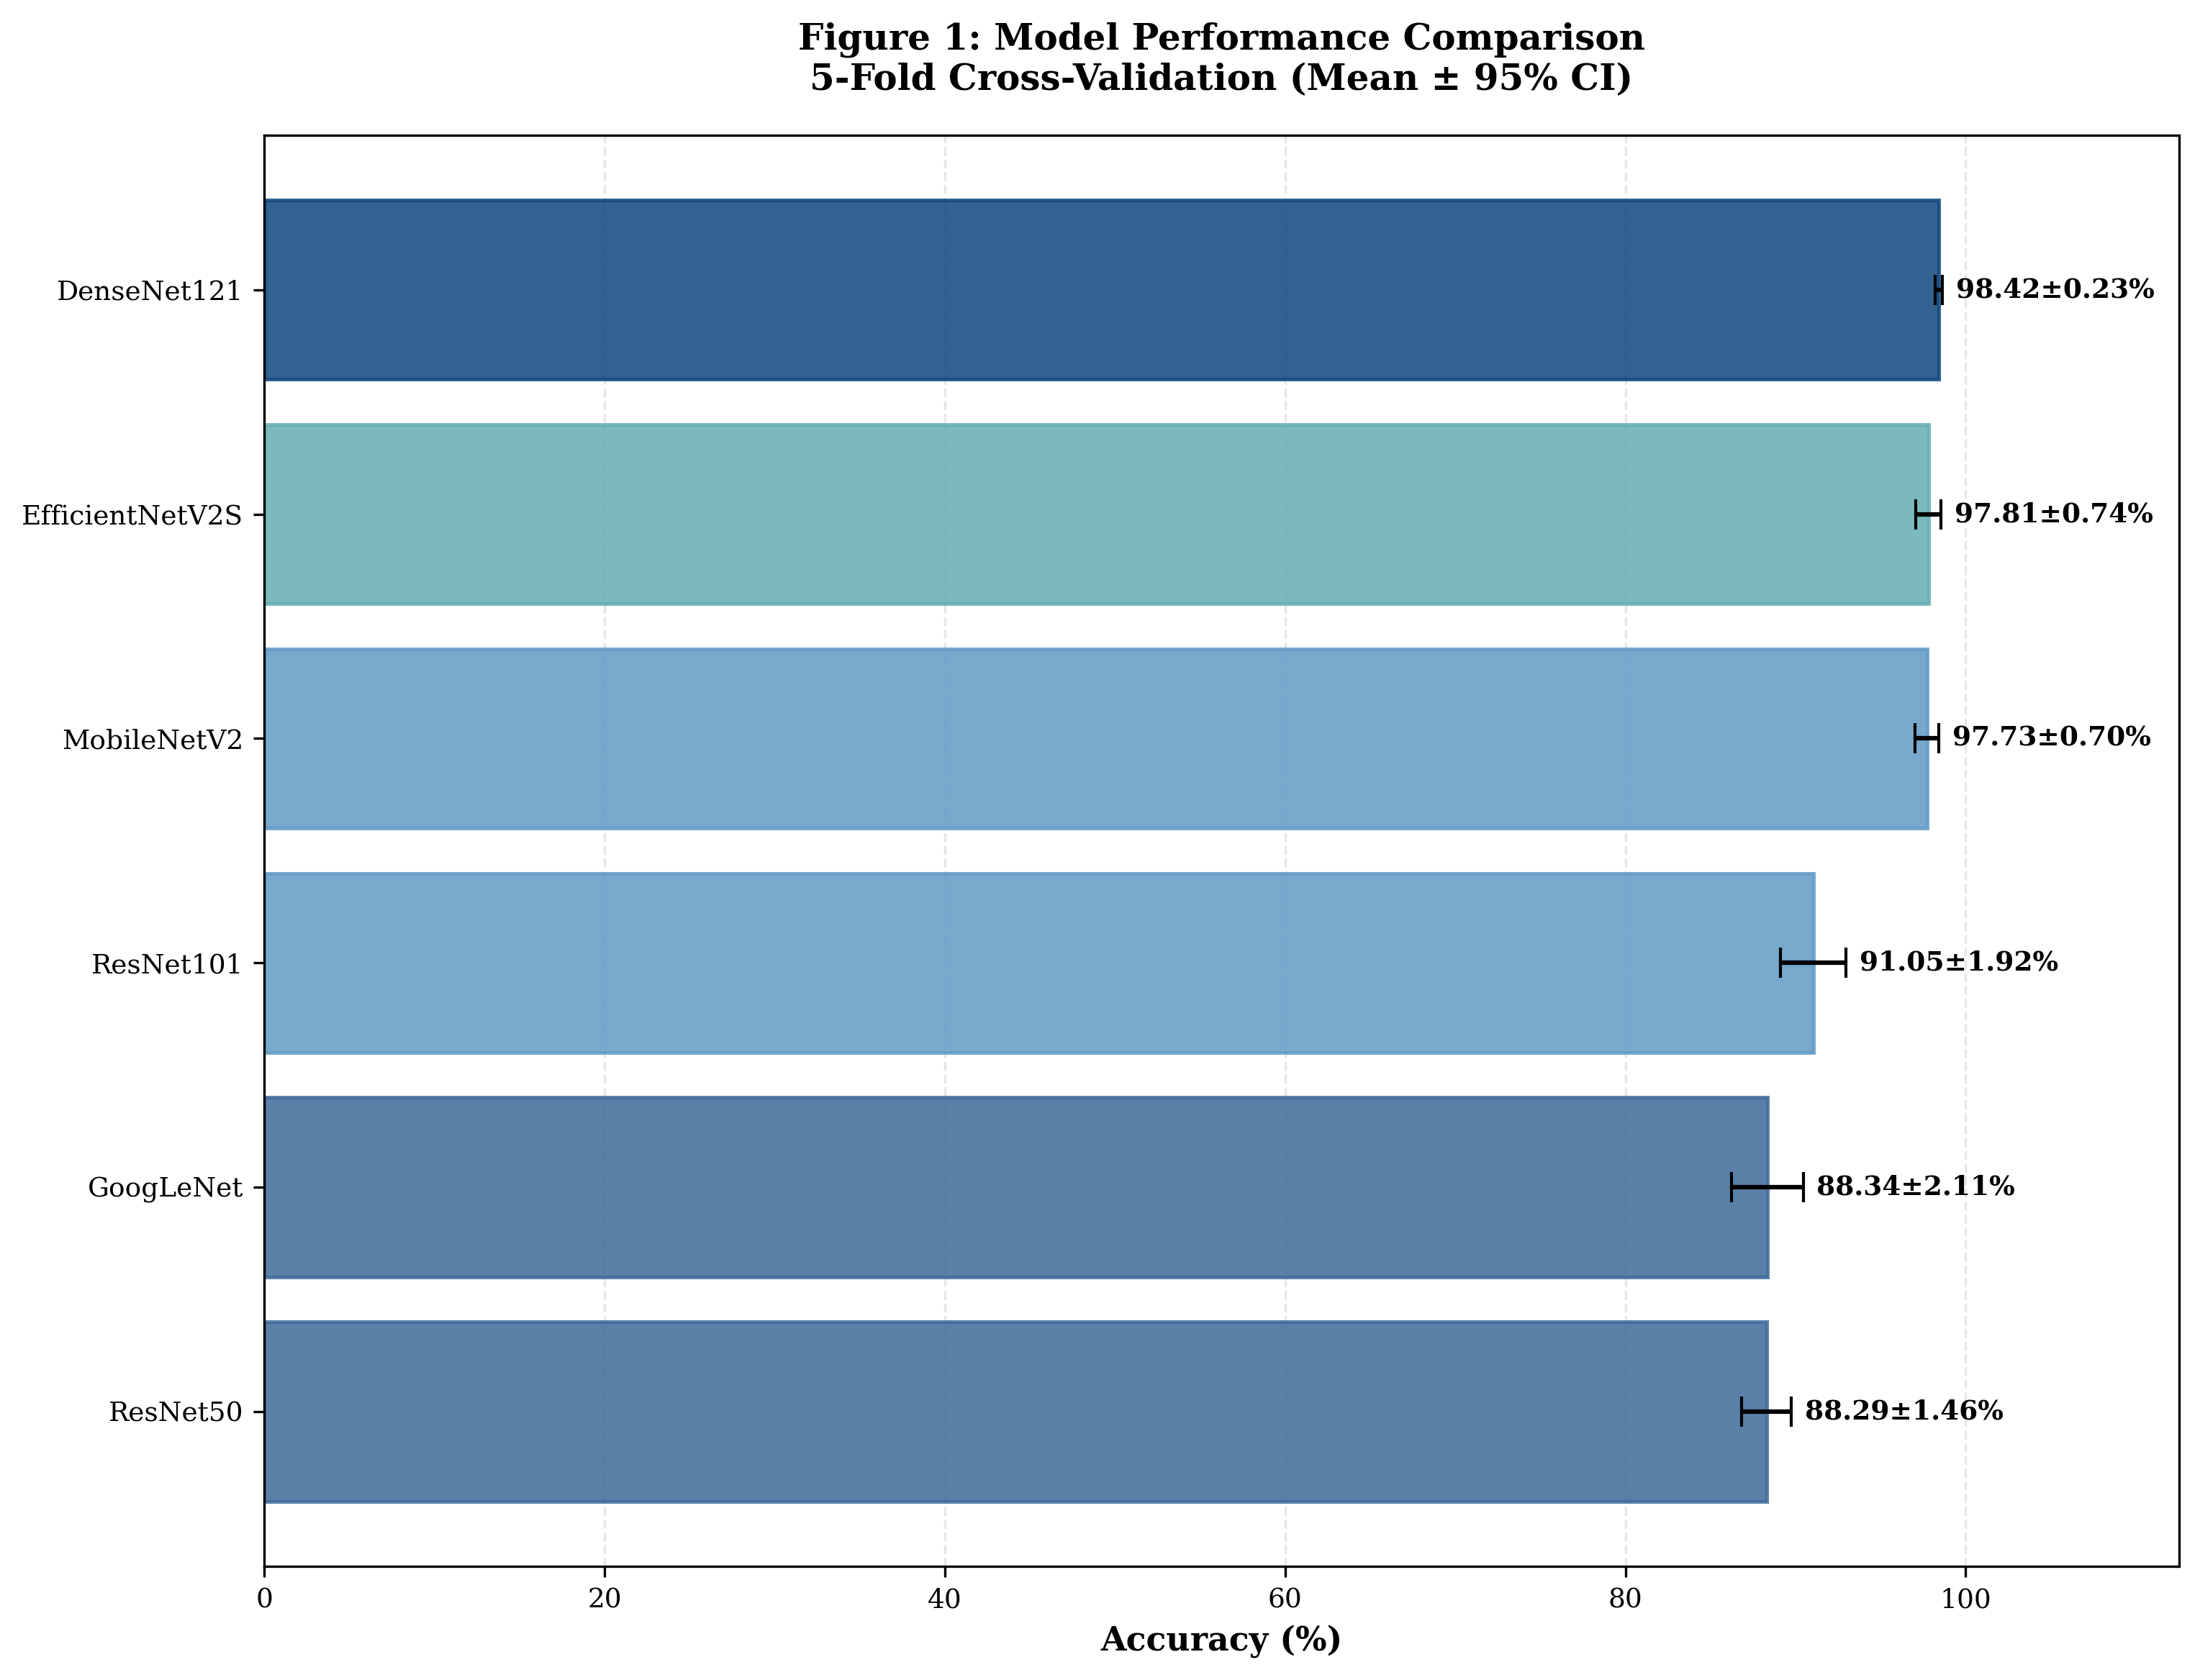

Saved: results/comparison/figures/fig1_accuracy_comparison.png


In [35]:
# Figure 1: Mean Accuracy with 95% Confidence Intervals
fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)

# Prepare data
plot_data = cv_metrics.sort_values('Mean_Accuracy', ascending=True).copy()
plot_data['Mean_Acc_Pct'] = plot_data['Mean_Accuracy'] * 100
plot_data['Std_Acc_Pct'] = plot_data['Std_Accuracy'] * 100
plot_data['CI'] = 1.96 * plot_data['Std_Acc_Pct']

y_pos = np.arange(len(plot_data))

# Define custom color palette
custom_colors = ['#3d6a99', '#619ac5', '#64adb3', "#0f457e"]

# Create horizontal bar plot
bars = ax.barh(y_pos, plot_data['Mean_Acc_Pct'], 
               xerr=plot_data['CI'],
               alpha=0.85, capsize=5, 
               error_kw={'linewidth': 2, 'elinewidth': 1.5},
               edgecolor='black', linewidth=1.2)

# Apply custom colors based on performance ranking
# Top performers get lighter colors
n_models = len(plot_data)
color_indices = np.linspace(0, len(custom_colors)-1, n_models)
for i, (bar, color_idx) in enumerate(zip(bars, color_indices)):
    color = custom_colors[int(color_idx)]
    bar.set_color(color)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data['Model'])
ax.set_xlabel('Accuracy (%)', fontweight='bold')
ax.set_title('Figure 1: Model Performance Comparison\n5-Fold Cross-Validation (Mean ± 95% CI)', 
             fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Extend x-axis to prevent label cutoff
max_val = plot_data['Mean_Acc_Pct'].max() + plot_data['CI'].max()
ax.set_xlim(0, max_val + 12)  # Add extra space for labels

# Add value labels inside or next to bars
for i, (idx, row) in enumerate(plot_data.iterrows()):
    label = f"{row['Mean_Acc_Pct']:.2f}±{row['CI']:.2f}%"
    # Position text at the end of error bars with some padding
    x_pos = row['Mean_Acc_Pct'] + row['CI'] + 0.8
    ax.text(x_pos, i, label, va='center', fontsize=9, fontweight='bold')

# Adjust layout to prevent cutoff
plt.tight_layout(pad=1.5)
plt.subplots_adjust(right=0.85)  # Add extra space on the right
output_path = FIGURES_DIR / 'fig1_accuracy_comparison.png'
plt.savefig(output_path, dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Saved: {output_path}")

### Figure 2: Per-Class F1-Score Heatmap

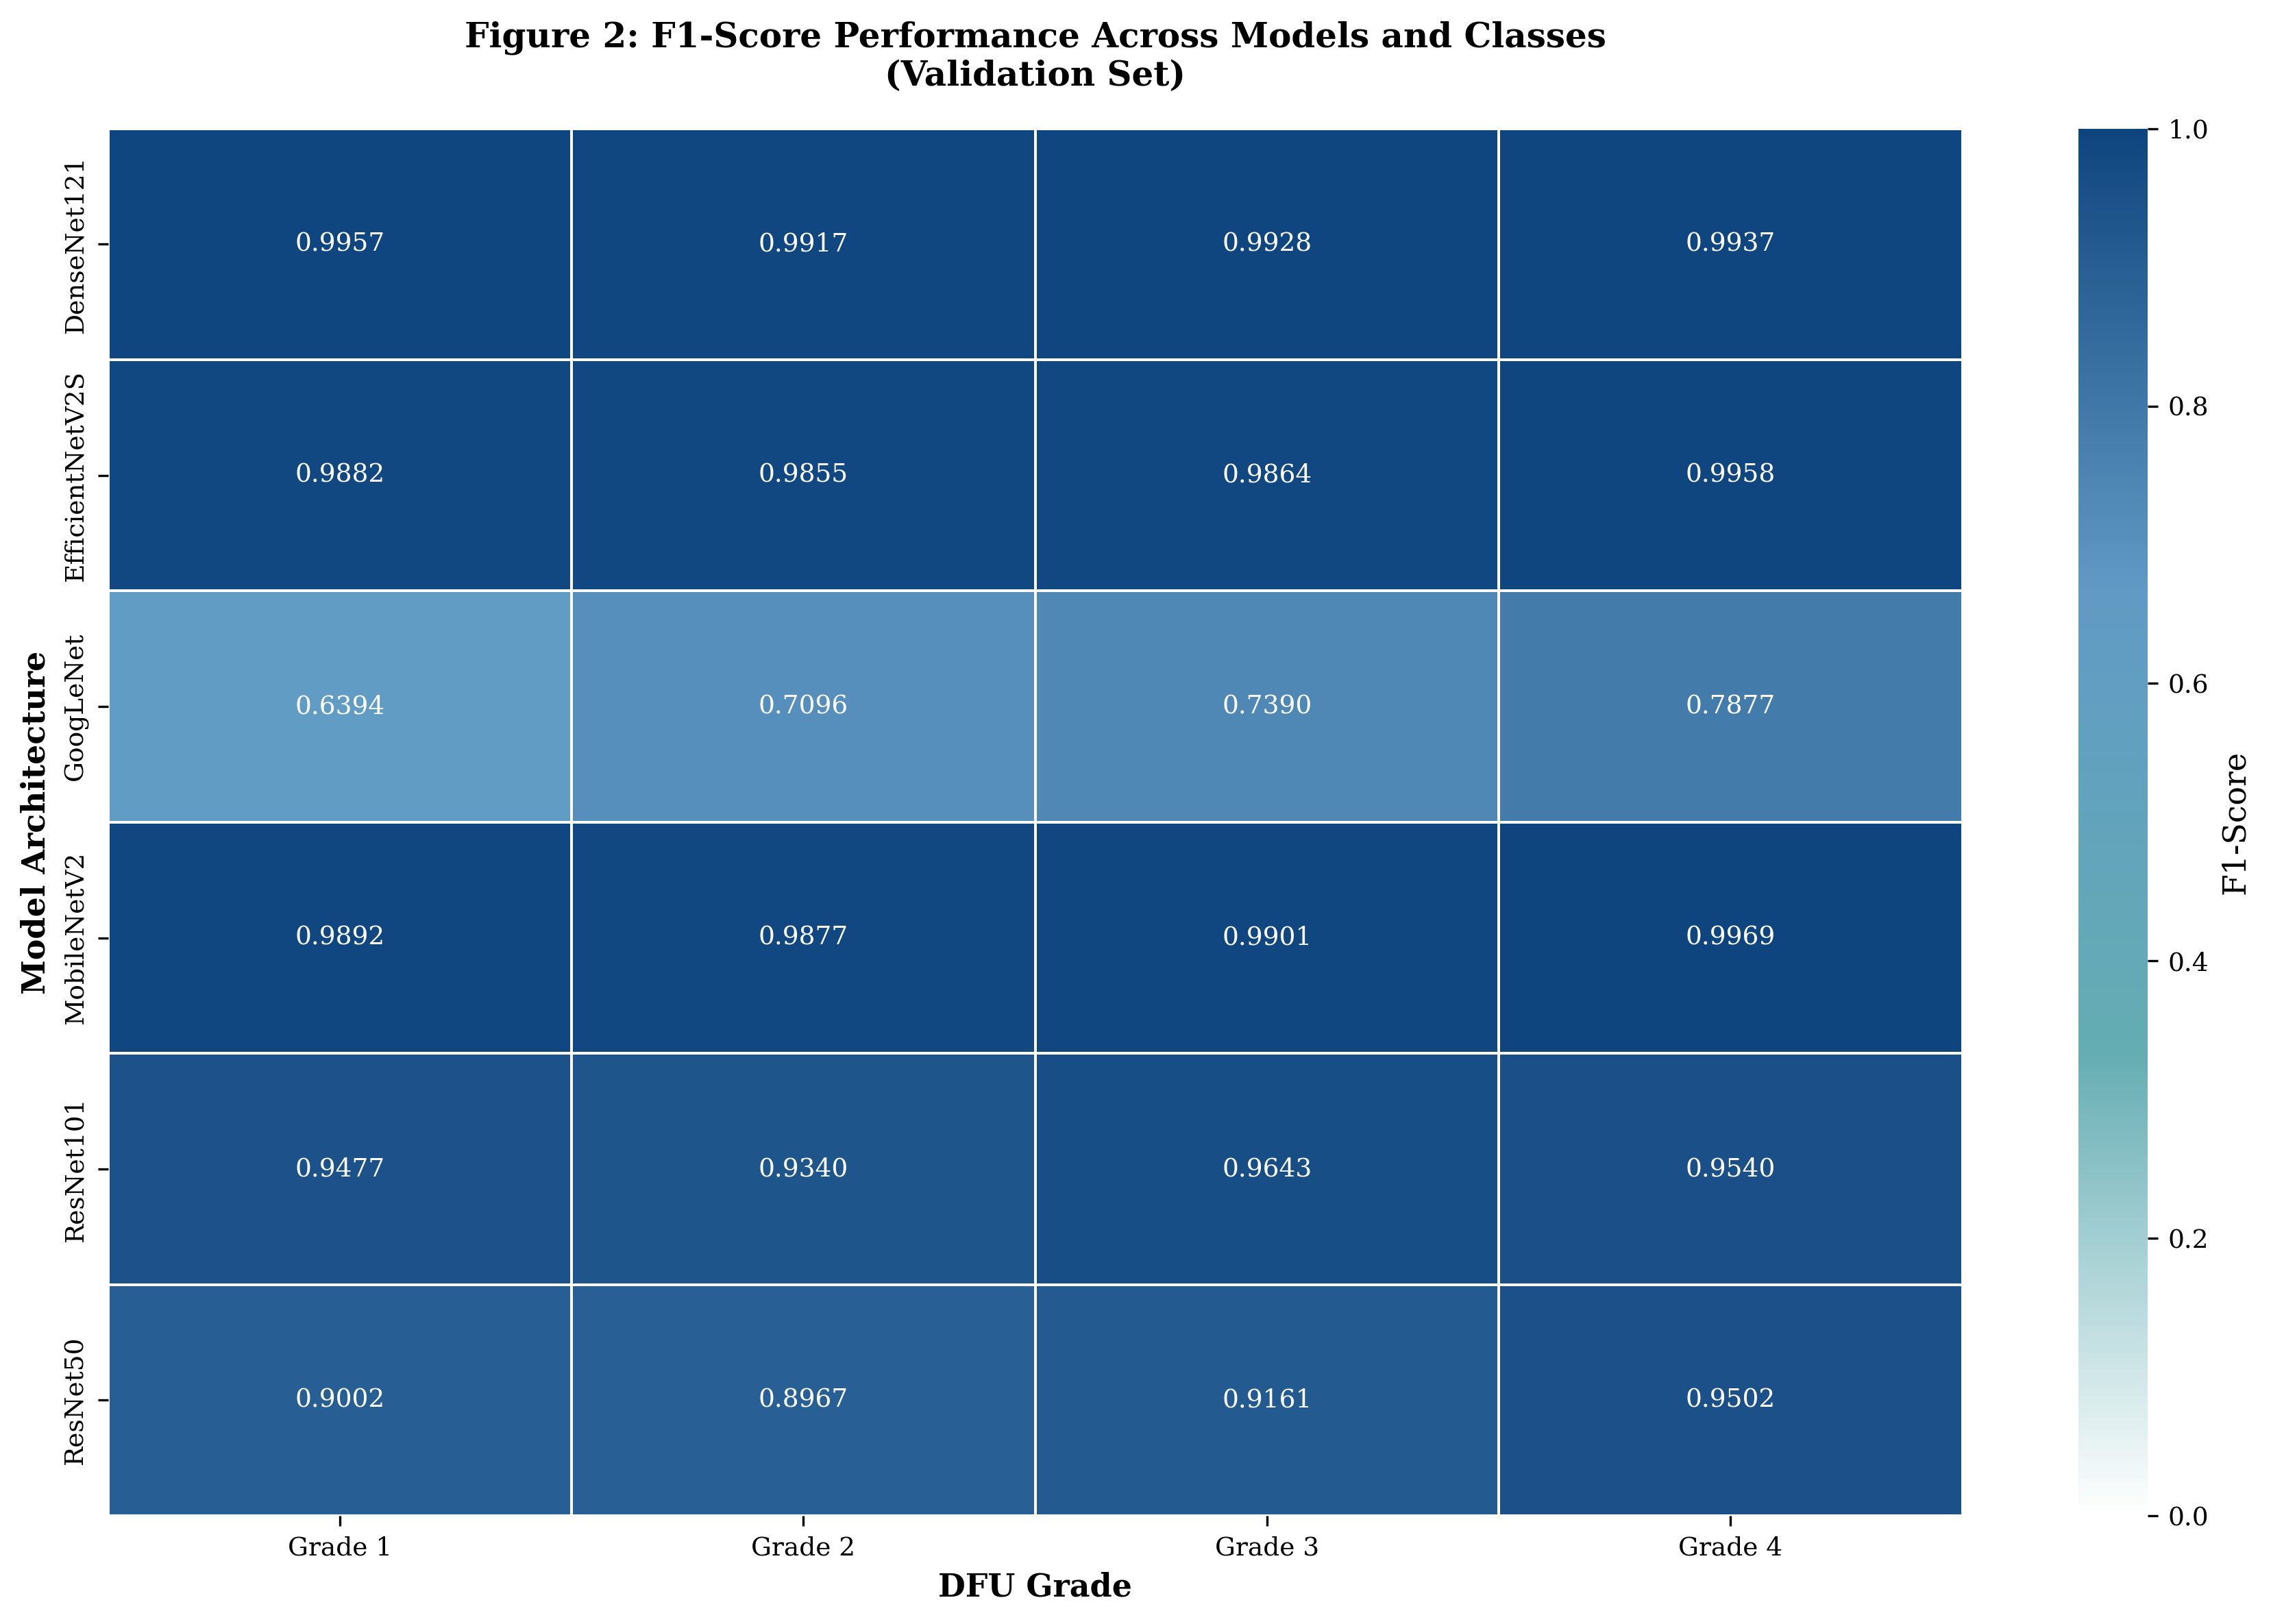

Saved: results/comparison/figures/fig2_f1_heatmap.png


In [33]:
# Figure 3: Heatmap of F1-Scores
fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)

pivot_f1 = per_class_df.pivot_table(values='F1_Score', index='Model', columns='Class', aggfunc='mean')

# Create custom colormap using the specified palette
from matplotlib.colors import LinearSegmentedColormap
custom_colors_list = ['#ffffff', '#64adb3', '#619ac5', "#0f457e"]  # White to dark blue
custom_cmap = LinearSegmentedColormap.from_list('custom_blues', custom_colors_list)

# Create heatmap
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap=custom_cmap, 
            linewidths=0.5, cbar_kws={'label': 'F1-Score'},
            vmin=0, vmax=1, ax=ax, square=False,
            annot_kws={'fontsize': 9})

ax.set_title('Figure 2: F1-Score Performance Across Models and Classes\n(Validation Set)', 
             fontweight='bold', pad=15)
ax.set_xlabel('DFU Grade', fontweight='bold')
ax.set_ylabel('Model Architecture', fontweight='bold')

plt.tight_layout()
output_path = FIGURES_DIR / 'fig2_f1_heatmap.png'
plt.savefig(output_path, dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Saved: {output_path}")

### Figure 3: Confusion Matrix Comparison

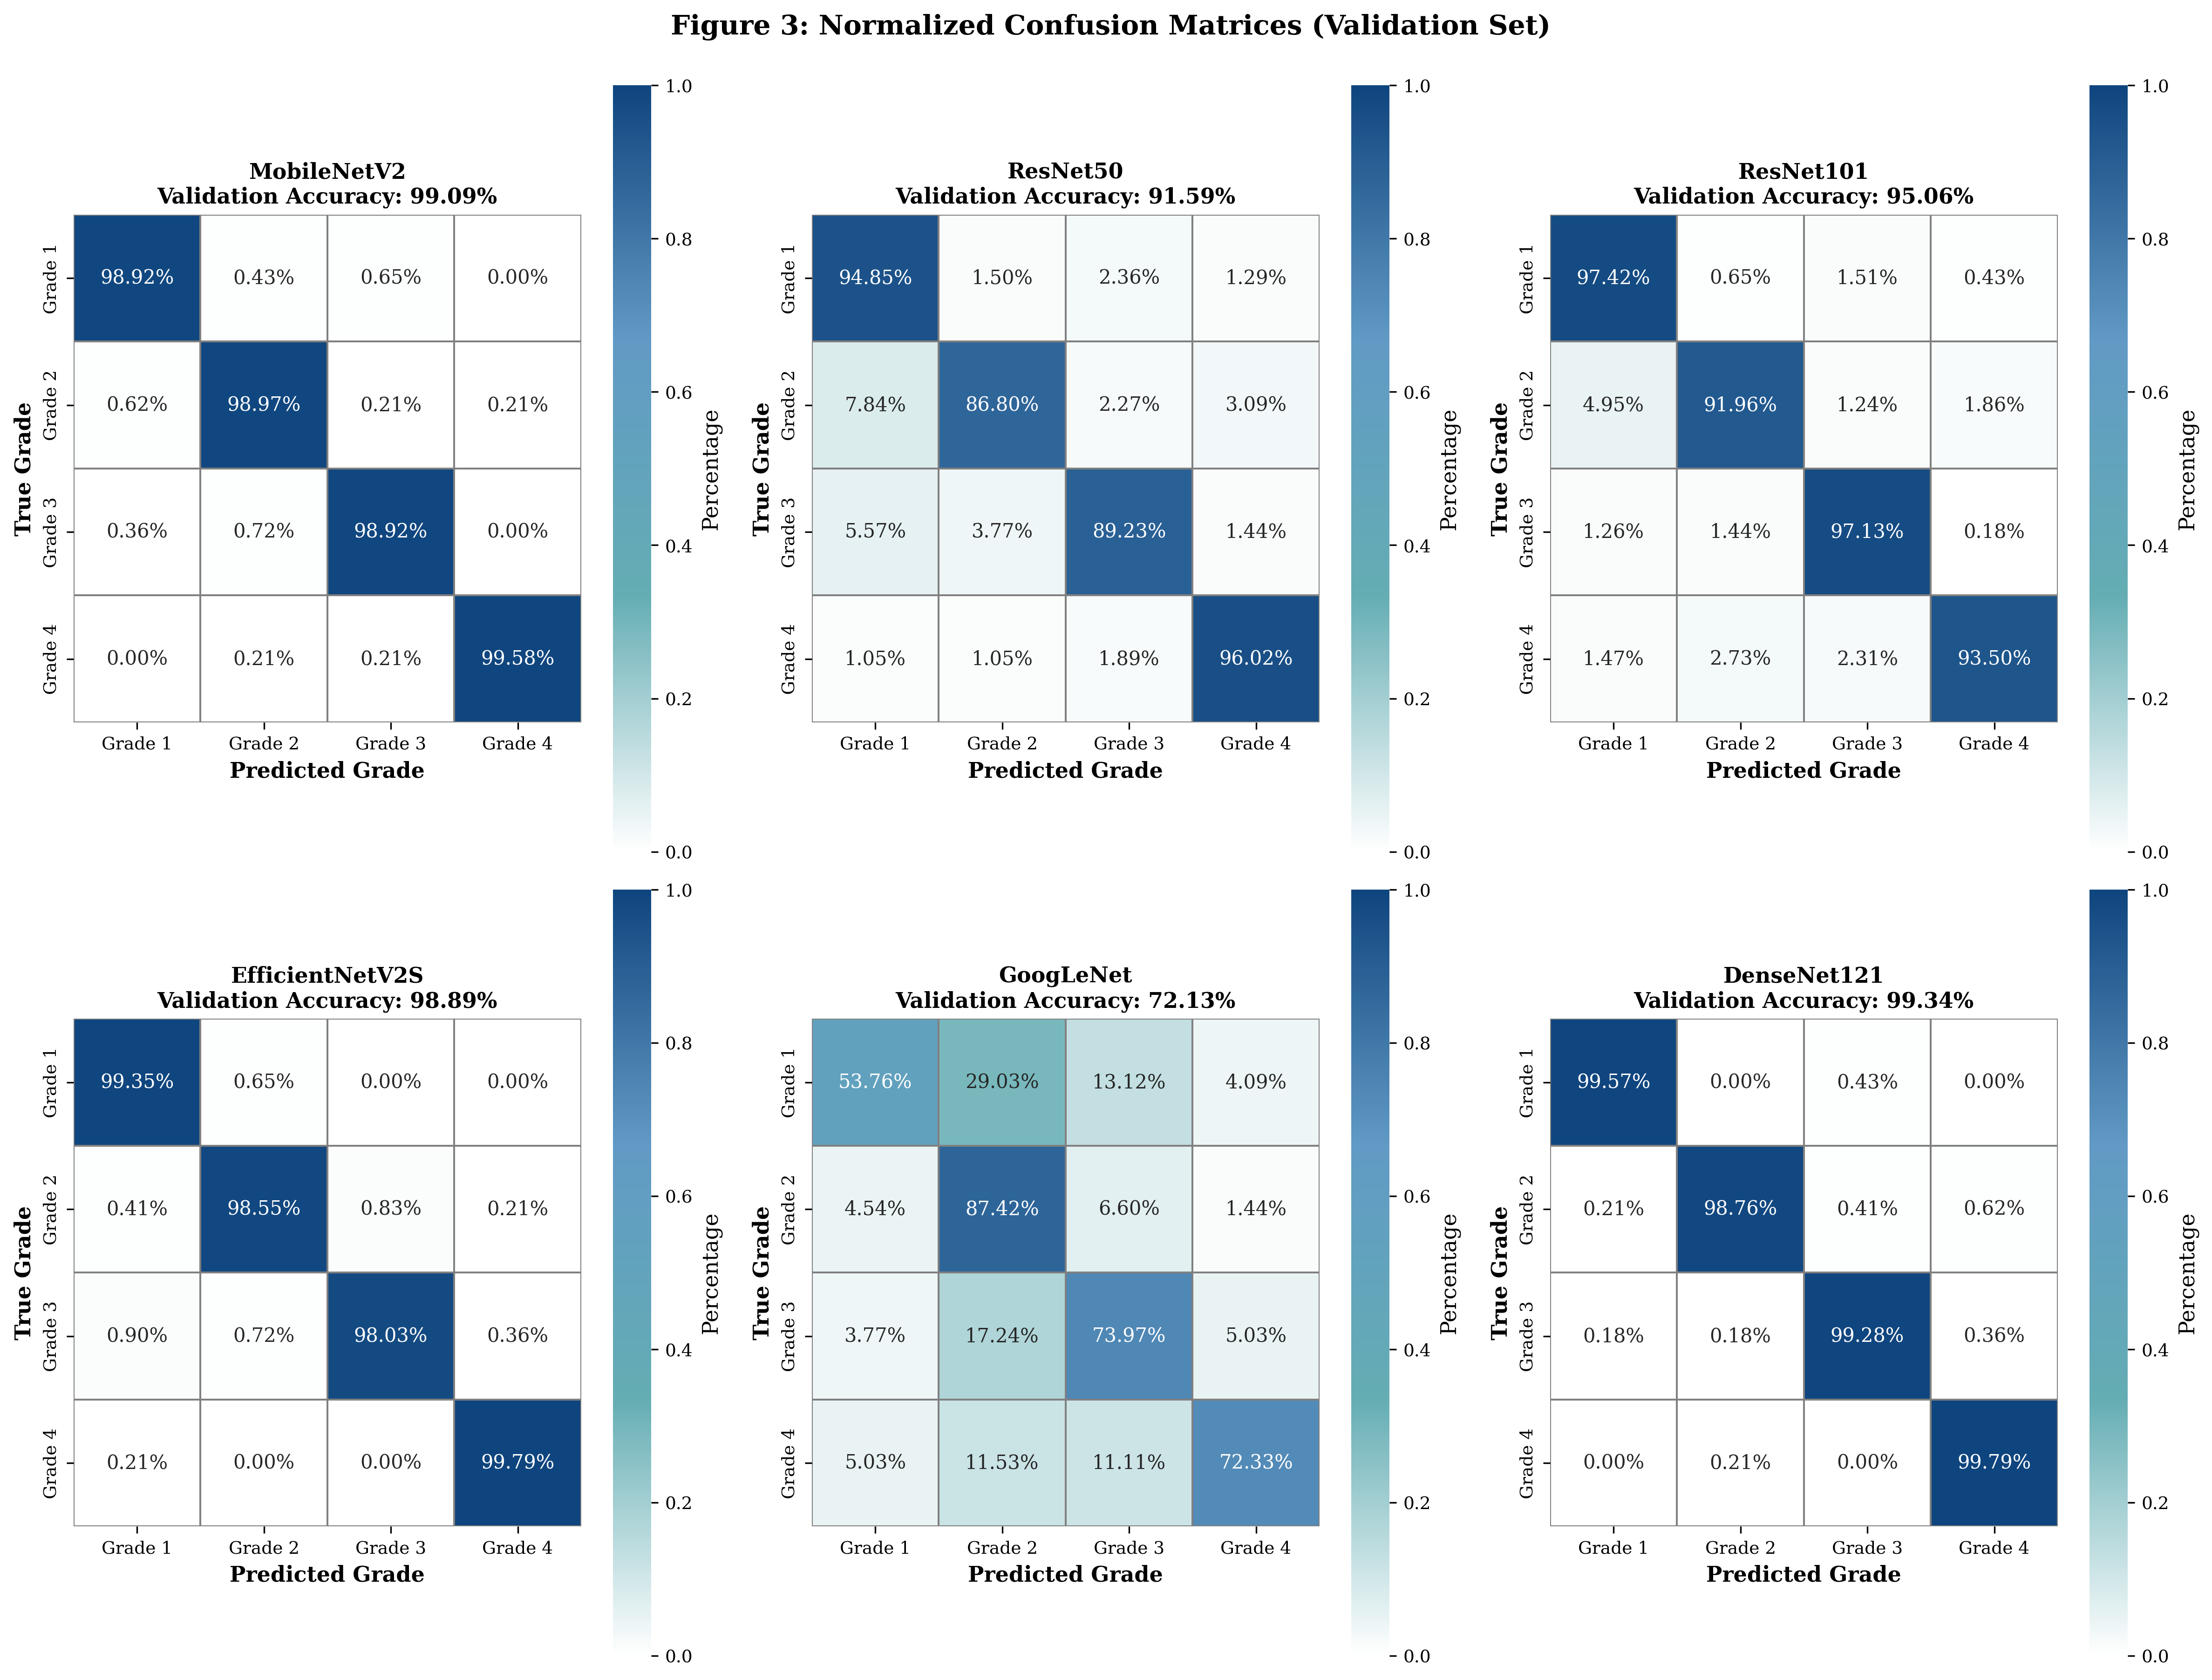

Saved: results/comparison/figures/fig3_confusion_matrices.png


In [34]:
# Figure 5: Normalized confusion matrices for all models
n_models = len(models)
cols = 3
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 6*rows))
axes = axes.flatten() if n_models > 1 else [axes]

# Create custom colormap using the specified palette
from matplotlib.colors import LinearSegmentedColormap
custom_colors_list = ['#ffffff', '#64adb3', '#619ac5', "#0f457e"]  # White to dark blue
custom_cmap = LinearSegmentedColormap.from_list('custom_blues', custom_colors_list)

for idx, (model_name, results) in enumerate(models.items()):
    ax = axes[idx]
    
    cm = np.array(results['validation_results']['confusion_matrix']['normalized'])
    labels = results['validation_results']['confusion_matrix']['labels']
    model_display_name = results['model_info']['model_name']
    accuracy = results['validation_results']['accuracy']
    
    # Create heatmap with custom colormap
    sns.heatmap(cm, annot=True, fmt='.2%', cmap=custom_cmap,
                xticklabels=labels, yticklabels=labels, ax=ax,
                cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1,
                square=True, linewidths=0.5, linecolor='gray')
    
    ax.set_title(f'{model_display_name}\nValidation Accuracy: {accuracy*100:.2f}%', 
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Grade', fontweight='bold')
    ax.set_ylabel('True Grade', fontweight='bold')

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Figure 3: Normalized Confusion Matrices (Validation Set)', 
             fontsize=14, fontweight='bold', y=0.998)
plt.tight_layout()
output_path = FIGURES_DIR / 'fig3_confusion_matrices.png'
plt.savefig(output_path, dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Saved: {output_path}")

## 6. Clinical Interpretation and Discussion

### 6.1 Model Performance Summary

In [26]:
# Generate clinical interpretation
print("\n" + "="*100)
print("CLINICAL PERFORMANCE INTERPRETATION")
print("="*100)

# Get top model
top_model = ranking_table.iloc[0]

print(f"\n1. BEST OVERALL PERFORMANCE: {top_model['Model']}")
print(f"   - Cross-Validation Accuracy: {top_model['CV_Accuracy']:.2f}% ± {top_model['CV_Std']:.2f}%")
print(f"   - Macro F1-Score: {top_model['Macro_F1']:.4f}")
print(f"   - Macro AUC-ROC: {top_model['Macro_AUC']:.4f}")
print(f"   - Clinical Metrics: Sensitivity = {top_model['Sensitivity']:.4f}, Specificity = {top_model['Specificity']:.4f}")
print(f"   - Training Efficiency: {top_model['Epochs']:.1f} epochs")

# Most consistent
most_consistent = ranking_table.sort_values('CV_Std').iloc[0]
print(f"\n2. MOST CONSISTENT PERFORMANCE: {most_consistent['Model']}")
print(f"   - Standard Deviation: {most_consistent['CV_Std']:.2f}%")
print(f"   - Clinical Relevance: Lower variance suggests more reliable performance across patient cohorts")

# Most efficient
most_efficient = ranking_table.sort_values('Epochs').iloc[0]
print(f"\n3. FASTEST CONVERGENCE: {most_efficient['Model']}")
print(f"   - Average Epochs: {most_efficient['Epochs']:.1f}")
print(f"   - Practical Benefit: Reduced training time and computational resources")

# Best AUC
best_auc = ranking_table.sort_values('Macro_AUC', ascending=False).iloc[0]
print(f"\n4. BEST DISCRIMINATIVE ABILITY: {best_auc['Model']}")
print(f"   - Macro AUC-ROC: {best_auc['Macro_AUC']:.4f}")
print(f"   - Clinical Significance: Superior ability to distinguish between severity grades")

# Best sensitivity
best_sens = ranking_table.sort_values('Sensitivity', ascending=False).iloc[0]
print(f"\n5. BEST SENSITIVITY: {best_sens['Model']}")
print(f"   - Sensitivity: {best_sens['Sensitivity']:.4f}")
print(f"   - Clinical Impact: Minimizes false negatives, crucial for detecting severe cases")

print("\n" + "="*100)


CLINICAL PERFORMANCE INTERPRETATION

1. BEST OVERALL PERFORMANCE: DenseNet121
   - Cross-Validation Accuracy: 0.98% ± 0.00%
   - Macro F1-Score: 0.9935
   - Macro AUC-ROC: 0.9999
   - Clinical Metrics: Sensitivity = 0.9935, Specificity = 0.9978
   - Training Efficiency: 29.8 epochs

2. MOST CONSISTENT PERFORMANCE: DenseNet121
   - Standard Deviation: 0.00%
   - Clinical Relevance: Lower variance suggests more reliable performance across patient cohorts

3. FASTEST CONVERGENCE: MobileNetV2
   - Average Epochs: 27.8
   - Practical Benefit: Reduced training time and computational resources

4. BEST DISCRIMINATIVE ABILITY: DenseNet121
   - Macro AUC-ROC: 0.9999
   - Clinical Significance: Superior ability to distinguish between severity grades

5. BEST SENSITIVITY: DenseNet121
   - Sensitivity: 0.9935
   - Clinical Impact: Minimizes false negatives, crucial for detecting severe cases



### 6.2 Model Complexity Considerations

**Conceptual Analysis** (Requires model architecture details for precise FLOPs/parameters):

- **MobileNetV2**: Lightweight architecture (~3.5M parameters), optimized for mobile deployment
- **ResNet50**: Baseline deep network (~25.6M parameters), balanced complexity
- **ResNet101**: Deeper variant (~44.5M parameters), increased capacity
- **EfficientNetV2-S**: Compound scaling (~21.5M parameters), optimized efficiency
- **GoogLeNet**: Inception modules (~6.6M parameters), multi-scale features
- **DenseNet**: Dense connectivity (~7-20M parameters variant-dependent), feature reuse

**Clinical Deployment Considerations:**
- Mobile/edge devices: MobileNetV2, EfficientNetV2-S preferred
- Server-based systems: ResNet101, DenseNet acceptable
- Resource-constrained settings: Balance accuracy vs computational cost

## 7. Study Limitations

The following limitations should be considered when interpreting these results:

**1. Dataset Constraints and Generalizability**
- The evaluation is based on a single dataset source, which may not fully represent the heterogeneity of diabetic foot ulcers encountered in diverse clinical settings across different geographic regions, ethnic populations, and healthcare systems.
- Class imbalance in the dataset may affect model performance differently across severity grades, potentially leading to biased predictions favoring more prevalent classes.
- Limited sample size in certain severity grades may reduce the statistical power to detect true performance differences between models.

**2. Validation Strategy and Performance Estimation**
- Cross-validation was performed on a combined training and validation set; the test set was reserved for final evaluation, which was not included in this comparative analysis.
- Performance metrics reported here reflect validation set performance and may not fully generalize to unseen patient populations or real-world clinical scenarios.
- The stratified k-fold approach maintains class proportions but may not account for potential clustering effects (e.g., multiple images from the same patient).

**3. Clinical Applicability and External Validation**
- Model performance has not been validated on external datasets from different institutions or clinical environments, limiting conclusions about real-world generalizability.
- The lack of temporal validation (i.e., testing on data collected at different time periods) means model robustness to changes in imaging protocols, equipment, or patient demographics remains unclear.
- Clinical utility metrics such as impact on treatment decisions, inter-rater agreement with clinicians, or patient outcomes have not been assessed.

**4. Technical and Methodological Considerations**
- All models used transfer learning from ImageNet pre-training; performance may differ if trained from scratch or with domain-specific pre-training.
- Hyperparameter optimization was consistent across models but may not represent the optimal configuration for each individual architecture.
- Computational resource requirements and inference times were not comprehensively evaluated, which are critical factors for clinical deployment feasibility.

**5. Reporting and Interpretation Constraints**
- The study focuses on overall classification accuracy and macro-averaged metrics, which may obscure class-specific performance variations that are clinically relevant.
- Confidence intervals are based on cross-validation folds rather than bootstrap resampling, which may underestimate true uncertainty in performance estimates.
- The absence of calibration analysis means the reliability of model confidence scores for clinical decision-making has not been established.

## 8. Comprehensive Report Generation

## 9. Summary and Citation

### Citation Format (Suggested)

```
[Authors]. (Year). "Comparative Analysis of Deep Learning Architectures for 
Automated Diabetic Foot Ulcer Severity Classification." [Journal Name], 
[Volume]([Issue]), [Pages]. DOI: [...]
```

### Software and Dependencies

- Python 3.x
- PyTorch [version]
- scikit-learn [version]
- NumPy, Pandas, Matplotlib, Seaborn
- Statistical analysis: SciPy

### Data Availability

Dataset and trained model weights available upon reasonable request in accordance with institutional review board approval and data sharing agreements.

### Acknowledgments

[Add funding sources, institutional support, and acknowledgments]

---

**End of Analysis**